# AlphaGenome scoring: APC splice variants (Pathogenic vs Benign)

Scores the cleaned ClinVar APC variants (`data/apc_variants.csv`) with AlphaGenome's
splice-related scorers and compares Pathogenic vs Benign.

In [61]:
import os
from dotenv import load_dotenv
from alphagenome.models import dna_client

# Load environment variables from a .env file (expects API_KEY to be defined)
load_dotenv()
API_KEY = os.environ["API_KEY"]

# Create the AlphaGenome client
dna_model = dna_client.create(API_KEY)
dna_model

In [62]:
import pandas as pd
from alphagenome.data import genome

# Load the pre-filtered ClinVar APC variant table
variants_df = pd.read_csv("data/apc_variants.csv")
print(variants_df["label"].value_counts())

# AlphaGenome scores a variant in the context of a surrounding reference
# sequence window.
SEQUENCE_WINDOW = dna_client.SEQUENCE_LENGTH_1MB

# Convert each dataframe row into an AlphaGenome genome.Variant object
variants = [
    genome.Variant(
        chromosome=row.chrom,
        position=int(row.pos),
        reference_bases=row.ref,
        alternate_bases=row.alt,
        name=str(row.variation_id),
    )
    for row in variants_df.itertuples()
]
# For each variant, build the 1MB genomic interval centered on it
intervals = [v.reference_interval.resize(SEQUENCE_WINDOW) for v in variants]

len(variants), len(intervals)

label
Pathogenic    548
Benign        362
Name: count, dtype: int64


(910, 910)

In [63]:
from alphagenome.models import variant_scorers

#  SPLICE_SITES: how much the variant changes the predicted strength of
#  splice-donor/acceptor sites at specific positions in the gene.
#  SPLICE_SITE_USAGE: how much the variant changes the predicted
#  probability that an existing splice site actually gets used.
#  SPLICE_JUNCTIONS: how much the variant changes predicted splicing
#  between pairs of sites (e.g. exon inclusion/exclusion, junction usage).

SPLICE_SCORER_NAMES = ["SPLICE_SITES", "SPLICE_SITE_USAGE", "SPLICE_JUNCTIONS"]
splice_scorers = [variant_scorers.RECOMMENDED_VARIANT_SCORERS[name] for name in SPLICE_SCORER_NAMES]
splice_scorers

[GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None),
 GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None),
 SpliceJunctionScorer()]

In [64]:
# Smoke test on a handful of variants before scoring all of them.
import random

# Sample 5 variants
test_idx = random.Random(0).sample(range(len(variants)), 5)
test_scores = dna_model.score_variants(
    intervals=[intervals[i] for i in test_idx],
    variants=[variants[i] for i in test_idx],
    variant_scorers=splice_scorers,
)

variant_scorers.tidy_scores(test_scores)

100%|██████████| 5/5 [00:01<00:00,  4.53it/s]


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,raw_score,quantile_score
0,chr5:112843622:A>G,chr5:112319334-113367910:.,ENSG00000134982,APC,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.058472,0.985244
1,chr5:112843622:A>G,chr5:112319334-113367910:.,ENSG00000258864,ENSG00000258864,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.058472,0.985244
2,chr5:112843622:A>G,chr5:112319334-113367910:.,ENSG00000134982,APC,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007812,0.575647
3,chr5:112843622:A>G,chr5:112319334-113367910:.,ENSG00000258864,ENSG00000258864,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004211,0.150853
4,chr5:112843622:A>G,chr5:112319334-113367910:.,ENSG00000134982,APC,protein_coding,+,None,None,SPLICE_SITE_USAGE,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,0.003906,0.329268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24602,chr5:112767162:A>C,chr5:112242874-113291450:.,ENSG00000134982,APC,protein_coding,+,112766410,112775628,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,embryonic,,encode,0.277100,0.997682
24603,chr5:112767162:A>C,chr5:112242874-113291450:.,ENSG00000134982,APC,protein_coding,+,112766410,112775628,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,embryonic,,encode,0.282959,0.997759
24604,chr5:112767162:A>C,chr5:112242874-113291450:.,ENSG00000134982,APC,protein_coding,+,112766410,112775628,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,embryonic,,encode,0.265137,0.997682
24605,chr5:112767162:A>C,chr5:112242874-113291450:.,ENSG00000134982,APC,protein_coding,+,112766410,112775628,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,polyA plus RNA-seq,UBERON:0036149,suprapubic skin,tissue,adult,Skin_Not_Sun_Exposed_Suprapubic,gtex,0.137695,0.996020


In [65]:
# Score all variants. Checkpointed to disk since this hits the API ~910 times.
import os

TIDY_SCORES_PATH = "data/tidy_splice_scores.parquet"

# If the full scoring run was already done and saved, just reload
if os.path.exists(TIDY_SCORES_PATH):
    tidy = pd.read_parquet(TIDY_SCORES_PATH)
else:
    # Score every variant against its own 1MB interval
    scores = dna_model.score_variants(
        intervals=intervals,
        variants=variants,
        variant_scorers=splice_scorers,
        max_workers=5,
    )
    tidy = variant_scorers.tidy_scores(scores)

    # Save scores to parquet
    tidy["variant_id"] = tidy["variant_id"].astype(str)
    tidy["scored_interval"] = tidy["scored_interval"].astype(str)
    tidy.to_parquet(TIDY_SCORES_PATH, index=False)

tidy.shape

(4046730, 21)

## Core result

Summarize each variant's splice scores into one number, then compare
Pathogenic vs Benign

In [66]:
# Per-variant summary: max absolute quantile score among the splice scorers.

GENE = "APC"
other_genes = tidy.loc[tidy["gene_name"] != GENE, "gene_name"].unique().tolist()
apc_tidy = tidy[tidy["gene_name"] == GENE]
print(f"Dropped {len(tidy) - len(apc_tidy)} rows scored against other overlapping genes {other_genes}")

# Rebuild the same "chrom:pos:ref>alt" variant_id format that tidy_scores
# uses, on the original variants_df, so the two tables can be joined below.
variants_df["variant_id"] = (
    variants_df["chrom"] + ":" + variants_df["pos"].astype(str) + ":" +
    variants_df["ref"] + ">" + variants_df["alt"]
)

# Collapse all remaining APC rows per variant (across scorers, output types,
# and tracks/tissues) down to a single number: the largest |quantile_score|
# seen anywhere for that variant.
summary = (
    apc_tidy.assign(abs_q=apc_tidy["quantile_score"].abs())
        .groupby("variant_id")["abs_q"].max()
        .rename("summary_score")
        .reset_index()
)

# Attach the summary score back onto the original variant metadata (label,
# consequence, etc.)
scored = variants_df.merge(summary, on="variant_id", how="left")
n_missing = scored["summary_score"].isna().sum()
print(f"{n_missing} variants had no APC splice-scorer match "
      f"(e.g. far upstream of the annotated gene body) and are dropped")


scored = scored.dropna(subset=["summary_score"])
scored[["label", "summary_score"]].head()

Dropped 1642534 rows scored against other overlapping genes ['ENSG00000258864']
3 variants had no APC splice-scorer match (e.g. far upstream of the annotated gene body) and are dropped


,label,summary_score
3,Benign,0.997682
4,Benign,0.998696
5,Benign,0.996638
6,Benign,0.997346
7,Benign,0.993402


In [76]:
main = scored[scored["label"].isin(["Pathogenic", "Benign"])]

# Tag each variant with a coarse consequence bucket.
def simplify(c):
    c = str(c).lower()
    if "splice" in c: return "splice"
    if "nonsense" in c: return "nonsense"
    if "stop lost" in c: return "stop lost"
    if "missense" in c: return "missense"
    if "synonymous" in c: return "synonymous"
    return "other/noncoding"

main_csq = main.assign(csq=main["consequence"].map(simplify))
main_csq["csq"].value_counts()

csq
nonsense           494
synonymous         272
other/noncoding     85
splice              31
missense            24
stop lost            1
Name: count, dtype: int64

In [80]:
# Required summary: count, median, and two simple separation checks per
# group ("above the Benign median" and the stricter "above every Benign
# variant"). Run once on everything, and again restricted to variants whose
# consequence isn't nonsense -- the mechanism splice scorers can't catch.
def required_stats(df, name):
    b = df.loc[df["label"] == "Benign", "summary_score"]
    p = df.loc[df["label"] == "Pathogenic", "summary_score"]
    print(f"--- {name} ---")
    print(f"Count:  Pathogenic {len(p)}, Benign {len(b)}")
    print(f"Median: Pathogenic {p.median():.4f}, Benign {b.median():.4f}")
    print(f"Pathogenic above Benign median: {(p > b.median()).mean():.1%}")
    print(f"Pathogenic above every Benign:  {(p > b.max()).mean():.1%}\n")

required_stats(main_csq, "All variants")
required_stats(main_csq[~main_csq["csq"].isin(["nonsense", "stop lost"])], "Excluding nonsense / stop lost")

--- All variants ---
Count:  Pathogenic 548, Benign 359
Median: Pathogenic 0.9883, Benign 0.9842
Pathogenic above Benign median: 59.1%
Pathogenic above every Benign:  11.3%

--- Excluding nonsense / stop lost ---
Count:  Pathogenic 53, Benign 359
Median: Pathogenic 1.0000, Benign 0.9842
Pathogenic above Benign median: 100.0%
Pathogenic above every Benign:  98.1%



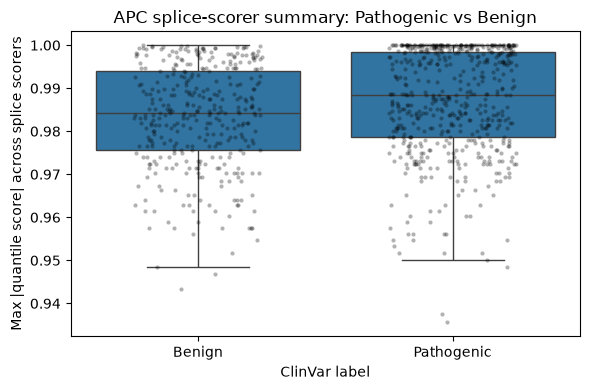

In [81]:
# Main figure: distribution of summary scores for Pathogenic vs Benign.

import matplotlib.pyplot as plt
import seaborn as sns

order = ["Benign", "Pathogenic"]
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=main, x="label", y="summary_score", order=order, showfliers=False, ax=ax)
sns.stripplot(data=main, x="label", y="summary_score", order=order,
              color="black", alpha=0.3, size=3, jitter=0.25, ax=ax)
ax.set_xlabel("ClinVar label")
ax.set_ylabel("Max |quantile score| across splice scorers")
ax.set_title("APC splice-scorer summary: Pathogenic vs Benign")
plt.tight_layout()
plt.savefig("data/pathogenic_vs_benign_splice_scores.png", dpi=150)
plt.show()

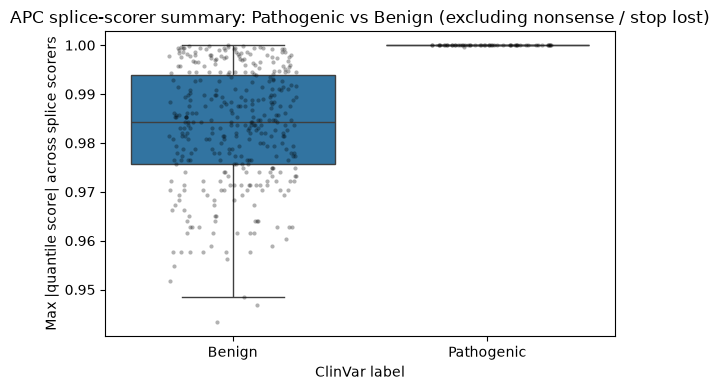

In [86]:
# Same comparison, restricted to variants whose consequence isn't nonsense
filtered = main_csq[~main_csq["csq"].isin(["nonsense", "stop lost"])]

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=filtered, x="label", y="summary_score", order=order, showfliers=False, ax=ax)
sns.stripplot(data=filtered, x="label", y="summary_score", order=order,
              color="black", alpha=0.3, size=3, jitter=0.25, ax=ax)
ax.set_xlabel("ClinVar label")
ax.set_ylabel("Max |quantile score| across splice scorers")
ax.set_title("APC splice-scorer summary: Pathogenic vs Benign (excluding nonsense / stop lost)")
plt.tight_layout()
plt.savefig("data/pathogenic_vs_benign_splice_scores_excl_nonsense.png", dpi=150)
plt.show()

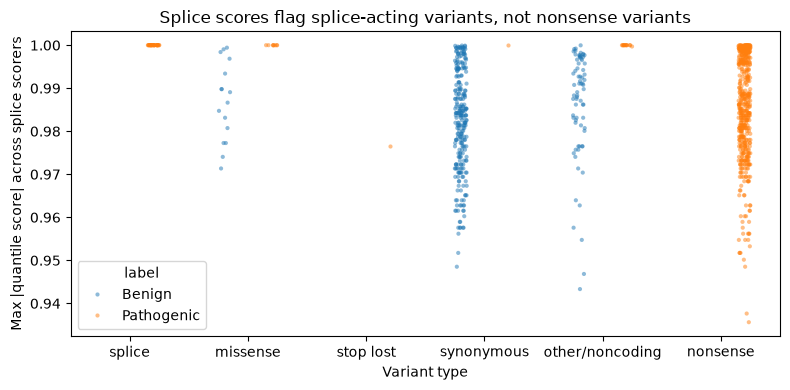

In [85]:
# Break the aggregate comparison apart by consequence type -- the figure
# version of what "Excluding nonsense" already showed in numbers above:
# splice scorers should only separate Pathogenic from Benign within
# mechanisms they can actually detect.
csq_order = ["splice", "missense", "stop lost", "synonymous", "other/noncoding", "nonsense"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=main_csq, x="csq", y="summary_score", hue="label", order=csq_order,
              hue_order=order, dodge=True, alpha=0.5, size=3, ax=ax)
ax.set_xlabel("Variant type")
ax.set_ylabel("Max |quantile score| across splice scorers")
ax.set_title("Splice scores flag splice-acting variants, not nonsense variants")
plt.tight_layout()
plt.savefig("data/scores_by_consequence.png", dpi=150)
plt.show()

### What separated:

- Across all variants, splice scores barely separated pathogenic from benign: 59% of pathogenic variants scored above the benign median, where 50% would be chance. But 494 of 548 pathogenic variants are nonsense, which harm the protein by truncating it rather than by changing splicing. Excluding nonsense and stop-lost variants, all 53 remaining pathogenic variants scored above the benign median, and 52 scored above every benign variant.

### One limit:

- The summary takes the maximum percentile across thousands of tissue tracks, which pushes nearly every variant toward 1.0. That compresses the visible gap between groups, and the excluded comparison rests on only 53 pathogenic variants.